---
title: 'LSE DS202W 2025: Week 03 - Student Notebook'
subtitle: Linear regression as a machine learning algorithm
author: MY NAME (MY CANDIDATE NUMBER)
date: 15 September 2025
jupyter: python3
---

In [51]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score, root_mean_squared_error
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from lets_plot import *
LetsPlot.setup_html()

## Before we do anything more

Please create a data folder called `data` to store all the different data sets in this course.

## Student Performance Dataset

In [52]:
students = pd.read_csv("../data/students-data.csv")
students = students.dropna()
print(students.shape)

(637, 31)


We start our machine learning journey with a student performance dataset (`students`), which contains information on students from two Portuguese schools. We have cleaned the data to only include statistically significant predictors. The columns include:

- `final_grade` final grade from 0 to 20 (**the outcome**)
- `school` student's school (binary: 'GP' - Gabriel Pereira or 'MS' - Mousinho da Silveira, reference: GP)
- `sex` student's sex (binary: 'F' - female or 'M' - male, reference: female)
- `age` student's age (numeric: from 15 to 22 years)
- `studytime` weekly study time (categorical: '<2hrs', '2-5hrs', '5-10hrs', '>10hrs', reference: <2hrs)
- `failures` number of past class failures (categorical: '0', '1', '2', '3', '4+', reference: 0 failures)
- `schoolsup` extra educational support (binary: yes or no, reference: no)
- `higher` wants to take higher education (binary: yes or no, reference: no)
- `goout` going out with friends frequency (categorical: 'VeryLow', 'Low', 'Average', 'High', 'VeryHigh', reference: VeryLow)
- `dalc` workday alcohol consumption (categorical: 'VeryLow', 'Low', 'Average', 'High', 'VeryHigh', reference: VeryLow)
- `health` current health status (categorical: 'VeryBad', 'Bad', 'Average', 'Good', 'VeryGood', reference: VeryBad)
- `romantic` in a romantic relationship (binary: yes or no, reference: no)

## Understanding student performance: some exploratory data analysis (EDA) (10 minutes)

Now it's your turn to explore the `students` dataset! Use this time to create visualizations and discover patterns in the data that might help explain what drives student success.

### Some ideas to get you started:

- How are final grades distributed? Are they normally distributed or skewed?
- Do students who want higher education perform better than those who don't?
- Is there a relationship between study time and final grades?
- How does past academic failure affect current performance?
- Are there differences in performance between the two schools?
- Does going out with friends impact academic performance?
- What's the relationship between health status and grades?
- Do students receiving extra educational support perform differently?
- How does alcohol consumption relate to academic performance?
- Are there gender differences in academic achievement?

### Challenge yourself:

- Can you find any surprising relationships in the data?
- What patterns emerge when you look at combinations of variables?
- Are there any outliers or interesting edge cases?

**Share your most interesting findings on Slack!** We'd love to see what patterns you discover and which visualizations tell the most compelling stories about student performance.

In [60]:
# Histogram of final scores
histogram = (
    ggplot(students, aes(x='final_grade')) +
    geom_histogram(binwidth=1, alpha=0.7, color='white', position='stack') +
    labs(
        title='Distribution of Student Final Grades',
        x='Final Grade',
        y='Number of Students')
)

histogram.show()

In [70]:
# Box plot of study time vs final grade
box_plot = (
    ggplot(students, aes(x='studytime', y='final_grade')) +
    geom_boxplot(alpha=0.7, color='blue') +
    labs(
        title='Final Grade by Study Time',
        x='Study Time (hours per week)',
        y='Average Final Grade')
)
box_plot.show()

## Understanding student performance: the hypothesis-testing approach (5 minutes)

Why do some students perform better than others? This is one question that a quantitative social scientist might answer by exploring the magnitude and precision of a series of variables. Suppose we hypothesised that students who want to pursue higher education have better academic performance. We can estimate a linear regression model by using `final_grade` as the dependent variable and `higher` as the independent variable.

To estimate a linear regression with interpretable output in Python, we can use the `sm.OLS` function, which requires two things:

- One or more features plus a constant
- An outcome

Let's do this now. We can print the summary method to get information on the coefficient estimate for `higher`.

In [72]:
# Convert higher to float (assuming it's binary: yes=1, no=0)
X = students["higher"].map({'yes': 1, 'no': 0}).astype(float)
# Add a constant
X = sm.add_constant(X)

# Isolate the outcome column
y = students["final_grade"]

# Build an OLS and print its output
model_univ = sm.OLS(y, X).fit()
print(model_univ.summary())

                            OLS Regression Results                            
Dep. Variable:            final_grade   R-squared:                       0.112
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     80.07
Date:                Tue, 03 Feb 2026   Prob (F-statistic):           3.94e-18
Time:                        10:08:33   Log-Likelihood:                -1615.6
No. Observations:                 637   AIC:                             3235.
Df Residuals:                     635   BIC:                             3244.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.7647      0.371     23.610      0.0

We see that students who want to pursue higher education have a positive and statistically significant (p < 0.001) increase in final grades of about 3.5 points.

👉 **NOTE:** The process of hypothesis testing is obviously more involved when using observational data than is portrayed by this simple example. Control variables will almost always be incorporated and, increasingly, identification strategies will be used to uncover causal effects. The end result, however, will involve as rigorous an attempt at falsifying a hypothesis as can be provided with the data.

For an example of how multivariate regression is used, we can run the following code.

In [75]:
# Create a function that standardises variables
def standardise(var):
    return (var - var.mean()) / var.std()

# Create a data frame of features
X = students.drop(["final_grade"], axis=1)

# Identify which features are numeric, categorical and boolean
X_numeric = X.filter(items=["age"], axis=1)
X_categorical = X.filter(items=["school", "sex", "studytime", "failures", "schoolsup", 
                                "higher", "goout", "dalc", "health", "romantic"], axis=1)

# standardise numeric features
X_numeric = X_numeric.apply(lambda x: standardise(x), axis=0)

# Get dummies from categorical features
X_categorical = pd.get_dummies(X_categorical, drop_first=True, dtype=int)

# Concatenate to final data frame
X = pd.concat([X_numeric, X_categorical], axis=1)

# Add a constant
X = sm.add_constant(X)

# ISOLATING OUR OUTCOME 
y = students["final_grade"]

In [76]:
# Code here
model_multi = sm.OLS(y, X).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:            final_grade   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     15.16
Date:                Tue, 03 Feb 2026   Prob (F-statistic):           1.12e-44
Time:                        10:08:56   Log-Likelihood:                -1515.2
No. Observations:                 637   AIC:                             3076.
Df Residuals:                     614   BIC:                             3179.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                11.5166      0.69

Interestingly, we can see that the coefficient estimate for `higher_yes` remains positive and highly significant (p < 0.001), suggesting this relationship holds even when controlling for other factors like study time, past failures, and demographic characteristics.

👉 **NOTE:** p-values are useful to machine learning scientists as they indicate which variables may yield a significant increase in model performance. However, p-hacking where researchers manipulate data to find results that support their hypothesis make it hard to tell whether or not a relationship held up after honest attempts at falsification. This can range from using a specific modelling approach that produces statistically significant (while failing to report others that do not) findings to outright manipulation of the data. For a recent egregious case of the latter, we recommend the [**Data Falsificada**](https://datacolada.org/archives/category/fake-data) series.

## Predicting student grades: the machine learning approach (30 minutes)

Machine learning scientists take a different approach. Our aim, in this context, is to build a model that can be used to accurately predict student performance using a mixture of features and, for some models, hyperparameters (which we will address in Lab 5).

*Thus, rather than attempting to falsify the effects of causes, we are more concerned about the fit of the model in the aggregate when applied to unforeseen data.*

To achieve this, we do the following:

- Split the data into training and test sets
- Build a model using the training set
- Evaluate the model on the test set

Let's look at each of these in turn.

### Split the data into training and test sets

It is worth considering what a training and test set is and why we might split the data this way.

A **training set** is data that we use to build (or "train") a model. In the case of multivariate linear regression, we are using the training data to estimate a series of coefficients. Here is a made-up multivariate linear model with three coefficients derived from (non-existent) data to illustrate things.

In [34]:
def sim_model_preds(x1, x2, x3):
    y = 1.1 * x1 + 2.2 * x2 + 3.3 * x3
    return y

A **test set** is data that the model has not yet seen. We then apply the model to this data set and use an evaluation metric to find out how accurate our predictions are. For example, suppose we had a new observation where `x1 = 10`, `x2 = 20` and `x3 = 30` and `y = 150`. We can use the above model to develop a prediction.

In [35]:
sim_model_preds(10, 20, 30)

154.0

We get a prediction of 154 points!

We can also calculate the amount of error we make by calculating residuals (actual value - predicted value).

In [36]:
# Code here

We can see that our model is 4 points off the real answer!

Why do we evaluate our models using different data? Because, as stated earlier, machine learning scientists care about the applicability of a model to *unforeseen* data. If we were to evaluate the model using the training data, we obviously cannot do this to begin with. Furthermore, we cannot ascertain whether the model we have built can generalise to other data sets or if the model has simply learned the idiosyncrasies of the data it was used to train on. We will discuss the concept of **overfitting** throughout this course.

We can use `train_test_split` in `sklearn.model_selection` to split the data into training and test sets.

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123)

👉 **NOTE:** Our data are purely cross-sectional, so we can use this approach. However, when working with more complex data structures (e.g. time series cross sectional), different approaches to splitting the data will need to be used.

### Build a model using the training set

We will now switch our focus from `statsmodels` to `scikit-learn`, the latter being Python's most comprehensive and popular machine learning library.

Below, we will see how simple it is to run a model in this library. We have done all the data cleaning needed, so we can just get to it!

In [81]:
# Create a model instance of a linear regression
linear_model = LinearRegression()

# Fit this instance to the training set
linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Evaluate the model using the test set

Now that we have trained a model, we can then evaluate its performance on the test set. We will look at two evaluation metrics:

- **R-squared**: the proportion of variance in the outcome explained by the model.
- **Root mean squared error (RMSE)**: the amount of error a typical observation parameterised as the units used in the initial measurement.

In [82]:
# Create predictions for the test set
linear_preds = linear_model.predict(X_test)

# Calculate performance metrics
r2 = r2_score(y_test, linear_preds)
rmse = root_mean_squared_error(y_test, linear_preds)

# Print results
print(np.round(r2, 2), np.round(rmse, 2))

0.27 2.47


🗣️ **CLASSROOM DISCUSSION:**

How can we interpret these results?

## Graphically exploring where we make errors

We are going to build some residual scatter plots which look at the relationship between the values fitted by the model for each observation and the residuals (actual - predicted values). Before we do this for our data, let's take a look at an example where there is a near perfect relationship between two variables. As this very rarely exists in the social world, we will rely upon simulated data.

We translated and adapted this code from [here](https://www.r-bloggers.com/2021/05/how-to-generate-correlated-data-in-r/).

In [40]:
# Set a seed for reproducibility
np.random.seed(123)

# Create the variance covariance matrix
sigma = [[1, 0.99], [0.99, 1]]

# Create the mean vector
mu = [10, 5]

# Generate a multivariate normal distribution using 1,000 samples
v1, v2 = np.random.multivariate_normal(mu, sigma, 1000).T

# Combine to a data frame
sim_data = pd.DataFrame({"V1": v1, "V2": v2})

### Plot the correlation

In [ ]:
# Code here


### Residual plots

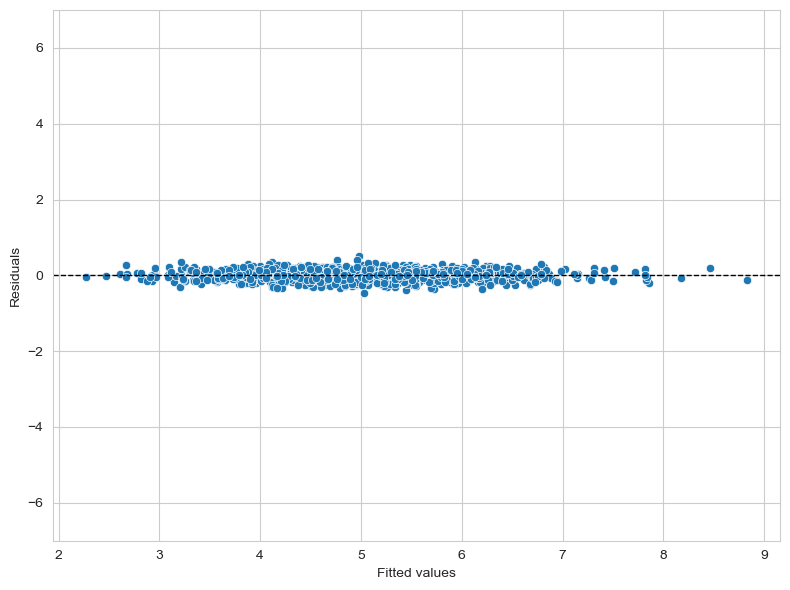

In [42]:
# Build a linear model
sim_fit = linear_model.fit(v1.reshape(-1, 1), v2.reshape(-1, 1)) 
sim_preds = linear_model.predict(v1.reshape(-1, 1))

# Combine predictions / residuals to a data frame
sim_residuals_toplot = pd.DataFrame({"predictions": sim_preds.reshape(-1),
                                     "residuals": v2 - sim_preds.reshape(-1)})

# Plot the results
plt.figure(figsize=(8, 6))
sns.scatterplot(data=sim_residuals_toplot, x="predictions", y="residuals")
plt.axhline(y=0, linestyle="--", color='black', linewidth=1)
plt.ylim(-7, 7)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
sns.set_style("whitegrid")
plt.grid(which='minor', visible=False)
plt.tight_layout()
plt.show()

Now let's run this code for our model.

In [ ]:
# Code here

🎯 **ACTION POINTS** why does the graph of the simulated data illustrate a more well-fitting model when compared to our actual data?

## Challenge: Running multiple univariate regressions efficiently (30 minutes)

🎯 **YOUR CHALLENGE:** Can you figure out how to run a univariate model for all features in the student dataset without creating 11 separate model objects?

Remember our univariate model earlier where we looked at `final_grade ~ higher`? Now we want to do the same thing for ALL features to see which individual variables are the strongest predictors of student performance.

The naive approach would be to copy-paste code 11 times and create 11 different model objects, but that's inefficient and error-prone. Your job is to find a more elegant solution!

In [44]:
# Code here

## Using penalised linear regression to perform feature selection (20 minutes)

We are now going to experiment with a lasso regression which, in this case, is a linear regression that uses a so-called **hyperparameter** - a "dial" built into a given model that can be experimented with to improve model performance. The hyperparameter in this case is a regularisation penalty which takes the value of a non-negative number. This penalty can shrink the magnitude of coefficients down to zero and the larger the penalty, the more shrinkage occurs.

### Step 1: Create a lasso model

Run the following code. This builds a lasso model with the penalty parameter set to `0.01`.

In [45]:
lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train, y_train)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


### Step 2: Extract lasso coefficients

In [46]:
# Create a data frame with feature columns and Lasso coefficients
lasso_output = pd.DataFrame({"feature": X_train.columns, "coefficient": lasso_model.coef_})

# Code a positive / negative vector
lasso_output["positive"] = np.where(lasso_output["coefficient"] >= 0, True, False)

# Take the absolute value of the coefficients
lasso_output["coefficient"] = np.abs(lasso_output["coefficient"])

# Remove the constant and sort the data frame by (absolute) coefficient magnitude
lasso_output = lasso_output.query("feature != 'const'").sort_values("coefficient")

In [47]:
lasso_output

,feature,coefficient,positive
16,dalc_VeryHigh,0.000000,True
10,goout_High,0.000000,True
17,dalc_VeryLow,0.020745,True
1,age,0.098501,True
21,health_VeryGood,0.175866,False
18,health_Bad,0.211407,True
11,goout_Low,0.340762,True
22,romantic_yes,0.347256,False
5,studytime_5-10hrs,0.378414,True
19,health_Good,0.422875,True


🎯 **ACTION POINTS** What is the output? Which coefficients have been shrunk to zero? What is the most important feature?

*Look at which features have coefficient values of 0 and which have the largest absolute coefficients. The most important features are those with the largest non-zero coefficients.*

### Step 3: Create a bar plot

In [48]:
# Code here

### Step 4: Evaluate on the test set

Although a different model is used, the code for evaluating the model on the test set is exactly the same as earlier.

In [49]:
# Code here

🗣️ **CLASSROOM DISCUSSION:**

What feature is the largest positive / negative predictor of student performance? Does this model represent an improvement on the linear model?

*Compare the R-squared and RMSE values to our earlier multivariate model. Does the lasso provide better predictive performance or feature selection benefits?*

### (Bonus) Step 5: Experiment with different penalties

This is your chance to try out different penalties. Can you find a penalty that improves test set performance?

*Let's try a lower penalty value of 0.001.*

In [50]:
# Code here

*Try different penalty values to see which gives you the lowest RMSE. How do the coefficients change as you increase the penalty?*

👉 **NOTE:** In labs 4 and 5, we are going to use a method called k-fold cross validation to systematically test different combinations of hyperparameters for models such as the lasso.